In [1]:
#import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from tsa_course.lecture1 import fft_analysis
from tsa_course.lecture2 import run_sequence_plot
from scipy import stats
from itertools import product
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import month_plot, plot_acf, plot_pacf
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.eval_measures import mse
from statsmodels.tsa.statespace.tools import diff
import warnings
from tqdm.notebook import tqdm
import time
import pmdarima as pm
import statsmodels as ss
import yfinance as yf

## Chapter 05

- Look at sensor data that tracks atmospheric CO2 from continuous air samples at Mauna Loa Observatory in Hawaii. This data includes CO2 samples from MAR 1958 to DEC 1980.

In [2]:
co2 = pd.read_csv('https://zenodo.org/records/10951538/files/arima_co2.csv?download=1', 
                  header = 0,
                  names = ['idx', 'co2'],
                  skipfooter = 2)

# convert the column idx into a datetime object and set it as the index
co2['idx'] = pd.to_datetime(co2['idx'])
co2.set_index('idx', inplace=True)

# Rmove the name "idx" from the index column
co2.index.name = None
co2

C:\Users\skief\AppData\Local\Temp\ipykernel_23860\1460310053.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  co2 = pd.read_csv('https://zenodo.org/records/10951538/files/arima_co2.csv?download=1',


,co2
1965-01-01,319.32
1965-02-01,320.36
1965-03-01,320.82
1965-04-01,322.06
1965-05-01,322.17
...,...
1980-08-01,337.19
1980-09-01,335.49
1980-10-01,336.63
1980-11-01,337.74


- Determine the presence of main trend and seasonality in the data.
- Determine if the data are stationary.
- Split the data in train (90%) and test (10%).

dominant period: 12.0


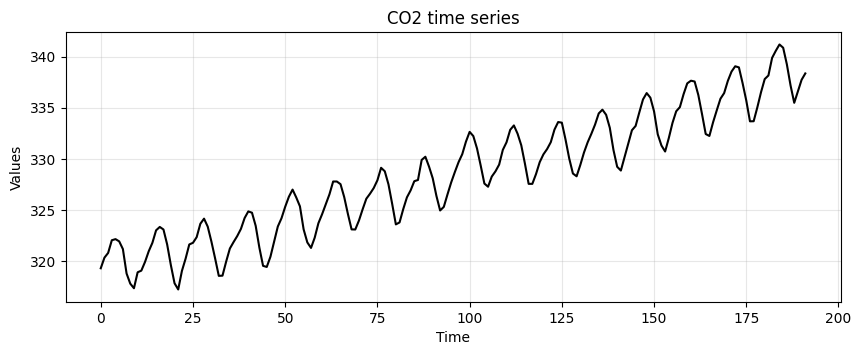

In [3]:
#visualize the time series --> always helpful
co2_time = np.arange(len(co2))
#reshape data into a 1D numpy array (it seems to be some list of shape (192,1))
co2 = np.array(co2).flatten()
run_sequence_plot(co2_time, co2, "CO2 time series")

period, _, _ = fft_analysis(np.array(co2))
print(f"dominant period: {period}")

Now that I know that the dominant period is 12 I can use seasonal decomposition to find out more about seasonality and trend. (I could also use np.polyfit() to find the trend and then do the same detrending as in the fft_analysis?)

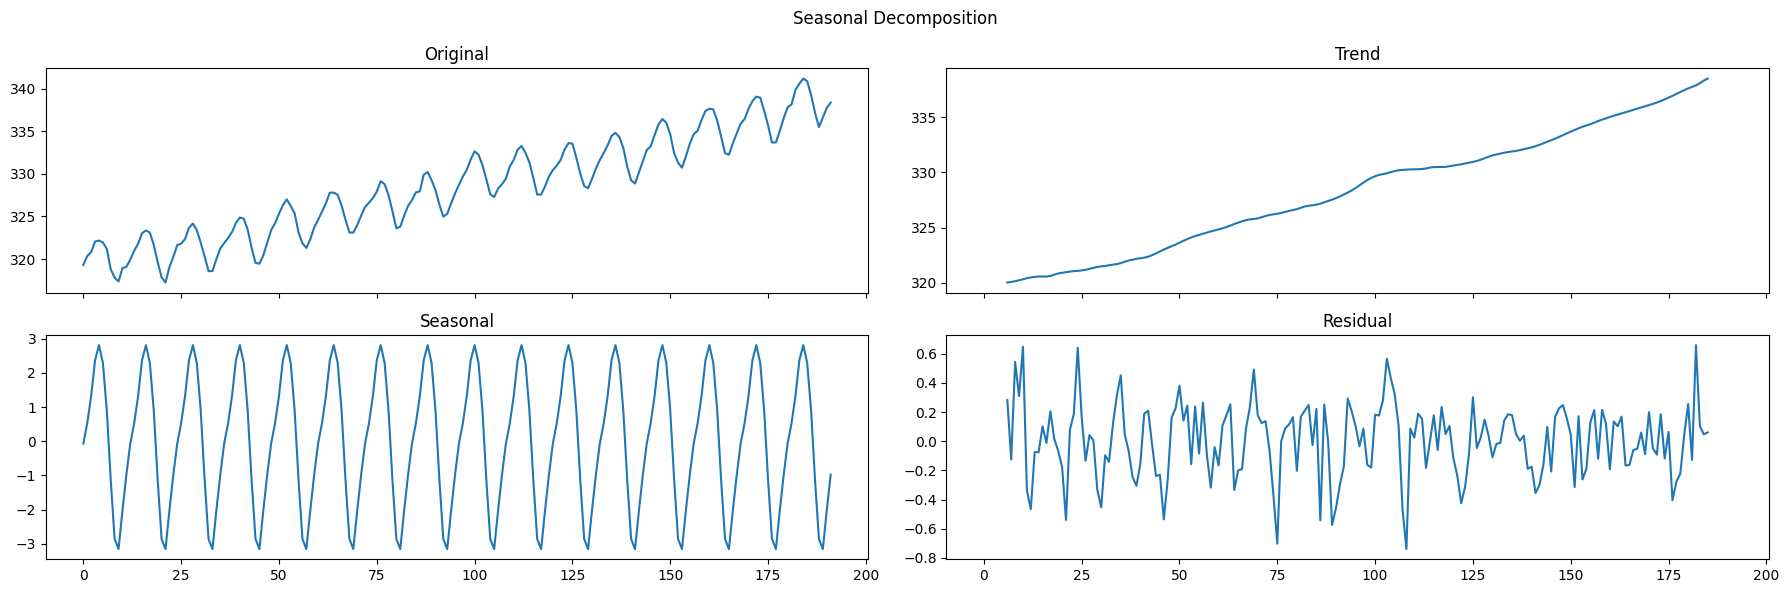

In [4]:
decomposition = seasonal_decompose(co2, "additive", period=12)

fig, axs = plt.subplots(2,2, sharex=True, figsize=(18,6))
axs[0,0].plot(co2)
axs[0,0].set_title('Original')
axs[0,1].plot(decomposition.trend)
axs[0,1].set_title('Trend')
axs[1,0].plot(decomposition.seasonal)
axs[1,0].set_title('Seasonal')
axs[1,1].plot(decomposition.resid)
axs[1,1].set_title('Residual')
plt.suptitle("Seasonal Decomposition")
plt.tight_layout()

The decomposition gives a good estimate for seasonality and also for the trend, even though it is a bit skewed. The residuals don`t have a obvious trend of seasonality anymore and look like noise. 

Now I need to determine stationarity. I already know the time series is not stationary as it has trend and seasonality. So I can first remove those components and then check again afterwards. I will do a Dickey-Fuller test before removing the components and afterwards to have a comparison.

ADF Statistic: 1.27
p-value: 0.996
Critical Values: ['1%: -3.47', '5%: -2.88', '10%: -2.58']

ADF Statistic: -5.05
p-value: 0.000
Critical Values: ['1%: -3.48', '5%: -2.88', '10%: -2.58']



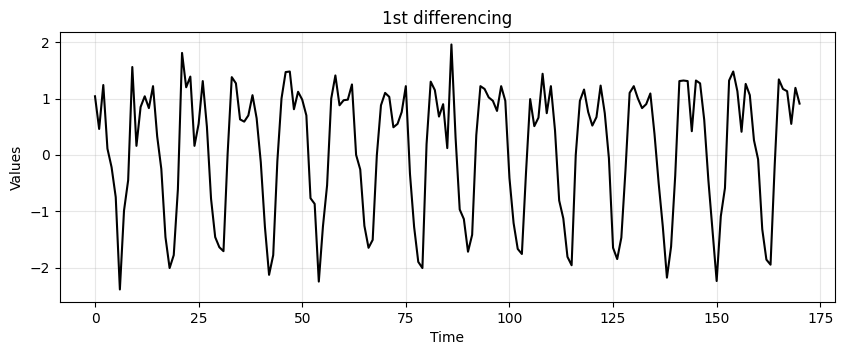

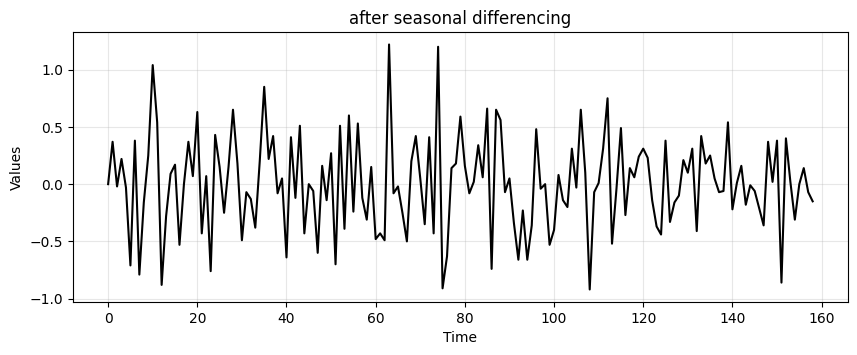

In [5]:
#split the data in test and train data
cut = int(0.9*len(co2))
co2_train = co2[:cut]
co2_test = co2[cut:]
time_train = co2_time[:cut]
time_test = co2_time[cut:]

#adf test on original data
test0 = adfuller(co2, autolag='AIC')
print(f'ADF Statistic: {test0[0]:.2f}')
print(f'p-value: {test0[1]:.3f}')
print(f"Critical Values: {[f'{k}: {r:.2f}' for r,k in zip(test0[4].values(), test0[4].keys())]}\n")

#try differencing to make model stationary
co2_detrended = co2_train[1:] - co2_train[:-1]
co2_detrended2 = co2_detrended[1:] - co2_detrended[:-1]
#seasonal differencing with period 12: 
co2_stat = co2_detrended[12:] - co2_detrended[:-12]
co2_stat2 = co2_detrended2[12:] - co2_detrended2[:-12]
co2_stat3 = co2_stat2[12:] - co2_stat2[:-12]

run_sequence_plot(time_train[:-1], co2_detrended, "1st differencing")
run_sequence_plot(time_train[:-13], co2_stat, "after seasonal differencing")

#adf test on stationary data
test0 = adfuller(co2_stat, autolag='AIC')
print(f'ADF Statistic: {test0[0]:.2f}')
print(f'p-value: {test0[1]:.3f}')
print(f"Critical Values: {[f'{k}: {r:.2f}' for r,k in zip(test0[4].values(), test0[4].keys())]}\n")

The ADF test indicates a good improvement in seasonality from the original to the differenced time series. This is also supported by the plots where there is still seasonality after the first differencing but noise-like data after the second differencing. 

- Find a set of SARIMAX candidate models by looking at the ACF and PACF.
- Perform a grid search on the model candidates.

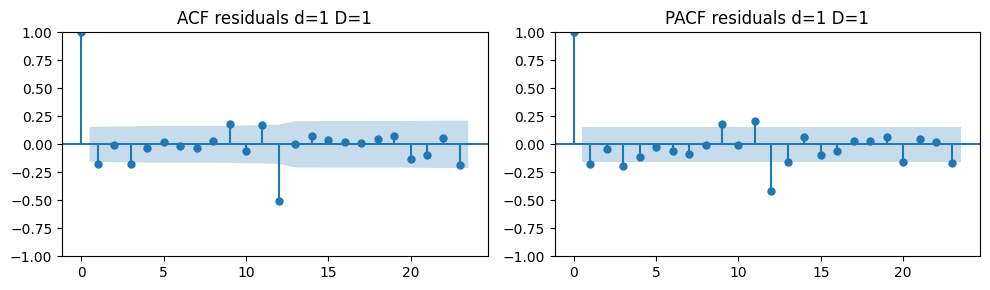

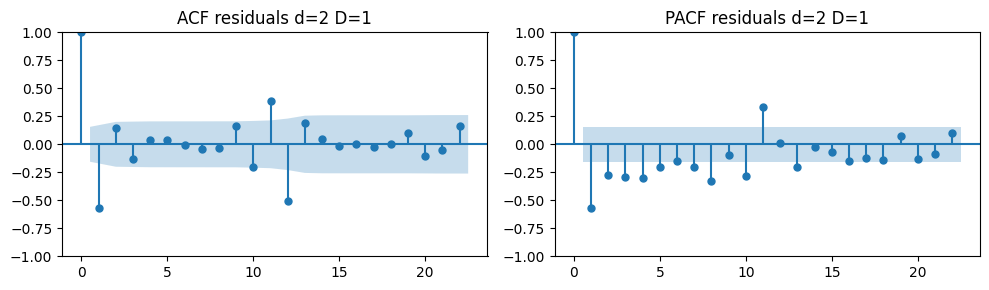

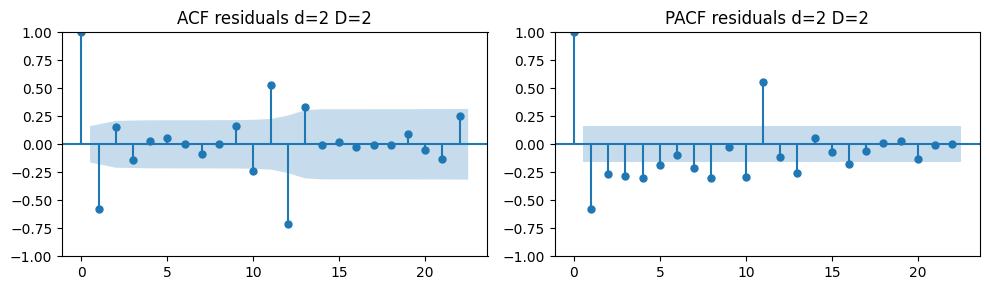

In [6]:
#ACF and PACF of the differenced series
_, axes = plt.subplots(1, 2, figsize=(10, 3))
plot_acf(co2_stat, ax=axes[0], title="ACF residuals d=1 D=1")
plot_pacf(co2_stat, ax=axes[1], title="PACF residuals d=1 D=1")
plt.tight_layout()

#not so helpful yet, more differencing?
_, axes = plt.subplots(1, 2, figsize=(10, 3))
plot_acf(co2_stat2, ax=axes[0], title="ACF residuals d=2 D=1")
plot_pacf(co2_stat2, ax=axes[1], title="PACF residuals d=2 D=1")
plt.tight_layout()

_, axes = plt.subplots(1, 2, figsize=(10, 3))
plot_acf(co2_stat3, ax=axes[0], title="ACF residuals d=2 D=2")
plot_pacf(co2_stat3, ax=axes[1], title="PACF residuals d=2 D=2")
plt.tight_layout()

indicates candidates q = (1,2,3) and p = (1,2,3,4,5)? And need d=2 , can do D=1 as there is no great improvement between D=1 and D=2. 

Look at the pacf and acf:

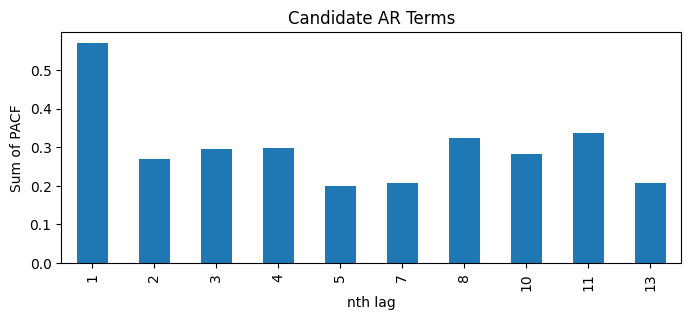

<Axes: title={'center': 'Candidate MA Terms'}, xlabel='nth lag', ylabel='Sum of ACF'>

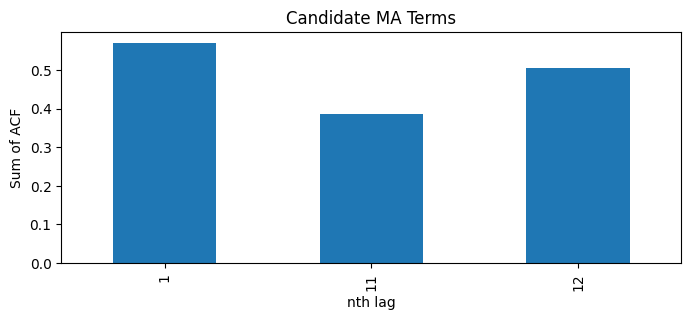

In [7]:
#use function from the lecture
passed_series = pd.DataFrame([co2_stat2]).T
df_sp_p = pd.DataFrame() # create an empty dataframe to store values of significant spikes in PACF plots
for i in passed_series:
    # unpack the results into PACF and their CI
    PACF, PACF_ci = pacf(passed_series[i].dropna(), alpha=0.05, method='ywm')
    # subtract the upper and lower limits of CI by PACF to centre CI at zero
    PACF_ci_ll = PACF_ci[:,0] - PACF
    PACF_ci_ul = PACF_ci[:,1] - PACF
    # find positions of significant spikes representing possible value of p & P
    sp1 = np.where(PACF < PACF_ci_ll)[0]
    sp2 = np.where(PACF > PACF_ci_ul)[0]
    # PACF values of the significant spikes
    sp1_value = abs(PACF[PACF < PACF_ci_ll])
    sp2_value = PACF[PACF > PACF_ci_ul]
    # store values to dataframe
    sp1_series = pd.Series(sp1_value, index=sp1)
    sp2_series = pd.Series(sp2_value, index=sp2)
    df_sp_p = pd.concat((df_sp_p, sp1_series, sp2_series), axis=1)
df_sp_p = df_sp_p.sort_index() # Sort the dataframe by index
# visualize sums of values of significant spikes in PACF plots ordered by lag
df_sp_p.iloc[1:].T.sum().plot(kind='bar', title='Candidate AR Terms', xlabel='nth lag', ylabel='Sum of PACF', figsize=(8,3))
plt.show()
df_sp_q = pd.DataFrame()
for i in passed_series:
    # unpack the results into ACF and their CI
    ACF, ACF_ci = acf(passed_series[i].dropna(), alpha=0.05)
    # subtract the upper and lower limits of CI by ACF to centre CI at zero
    ACF_ci_ll = ACF_ci[:,0] - ACF
    ACF_ci_ul = ACF_ci[:,1] - ACF
    # find positions of significant spikes representing possible value of q & Q
    sp1 = np.where(ACF < ACF_ci_ll)[0]
    sp2 = np.where(ACF > ACF_ci_ul)[0]
    # ACF values of the significant spikes
    sp1_value = abs(ACF[ACF < ACF_ci_ll])
    sp2_value = ACF[ACF > ACF_ci_ul]
    # store values to dataframe
    sp1_series = pd.Series(sp1_value, index=sp1)
    sp2_series = pd.Series(sp2_value, index=sp2)
    df_sp_q = pd.concat((df_sp_q, sp1_series, sp2_series), axis=1)
df_sp_q = df_sp_q.sort_index() # Sort the dataframe by index
# visualize sums of values of significant spikes in ACF plots ordered by lags
df_sp_q.iloc[1:].T.sum().plot(kind='bar', title='Candidate MA Terms', xlabel='nth lag', ylabel='Sum of ACF', figsize=(8,3))

Do a grid search with the candidates identified here. 

In [8]:
#define candidates
p = [1,2,3,4,5]
d = [2]
q = [1,2,3]
P = [1,2,3,4]
D = [1,2]
Q = [1]
s = [12]

# create all combinations of possible values
pdq = list(product(p, d, q))
PDQm = list(product(P, D, Q, s))

print(f"Number of total combinations: {len(pdq)*len(PDQm)}")

#train model
warnings.simplefilter("ignore")
def SARIMA_grid(endog, order, seasonal_order):

    # create an empty list to store values
    model_info = []
       
    #fit the model
    for i in tqdm(order):
        for j in seasonal_order:
            try:
                model_fit = SARIMAX(endog=endog, order=i, seasonal_order=j).fit(disp=False)
                predict = model_fit.predict()
            
                # calculate evaluation metrics: MAPE, RMSE, AIC & BIC
                MAPE = (abs((endog-predict)[1:])/(endog[1:])).mean()
                MSE = mse(endog[1:], predict[1:])
                AIC = model_fit.aic
                BIC = model_fit.bic
            
                # save order, seasonal order & evaluation metrics
                model_info.append([i, j, MAPE, MSE, AIC, BIC])
            except:
                continue
                
    # create a dataframe to store info of all models
    columns = ["order", "seasonal_order", "MAPE", "MSE", "AIC", "BIC"]
    model_info = pd.DataFrame(data=model_info, columns=columns)
    return model_info

start = time.time()

# fit all combinations into the model
model_info = SARIMA_grid(endog=co2_train, order=pdq, seasonal_order=PDQm)

end = time.time()
print(f'time required: {end - start :.2f}')

Number of total combinations: 120


  0%|          | 0/15 [00:00<?, ?it/s]

time required: 565.82


- Select the best models, based on performance metrics, model complexity, and normality of the residuals.

The best 4 models based on MAPE, MSE, AIC, BIC:

In [9]:
# the best model by each metric
L1 = model_info[model_info.MAPE == model_info.MAPE.min()]
L2 = model_info[model_info.MSE == model_info.MSE.min()]
L3 = model_info[model_info.AIC == model_info.AIC.min()]
L4 = model_info[model_info.BIC == model_info.BIC.min()]

best_models = pd.concat((L1, L2, L3, L4))
best_models

,order,seasonal_order,MAPE,MSE,AIC,BIC
92,"(4, 2, 3)","(3, 1, 1, 12)",0.007845,352.016877,103.502329,140.253469
112,"(5, 2, 3)","(1, 1, 1, 12)",0.007864,352.016291,97.284403,130.972948
112,"(5, 2, 3)","(1, 1, 1, 12)",0.007864,352.016291,97.284403,130.972948
0,"(1, 2, 1)","(1, 1, 1, 12)",0.007900,352.026563,104.030462,119.343437


Here the same model appears twice actually (nr 112), for performance and complexity. That`s a strong candidate. 

normality of residuals?

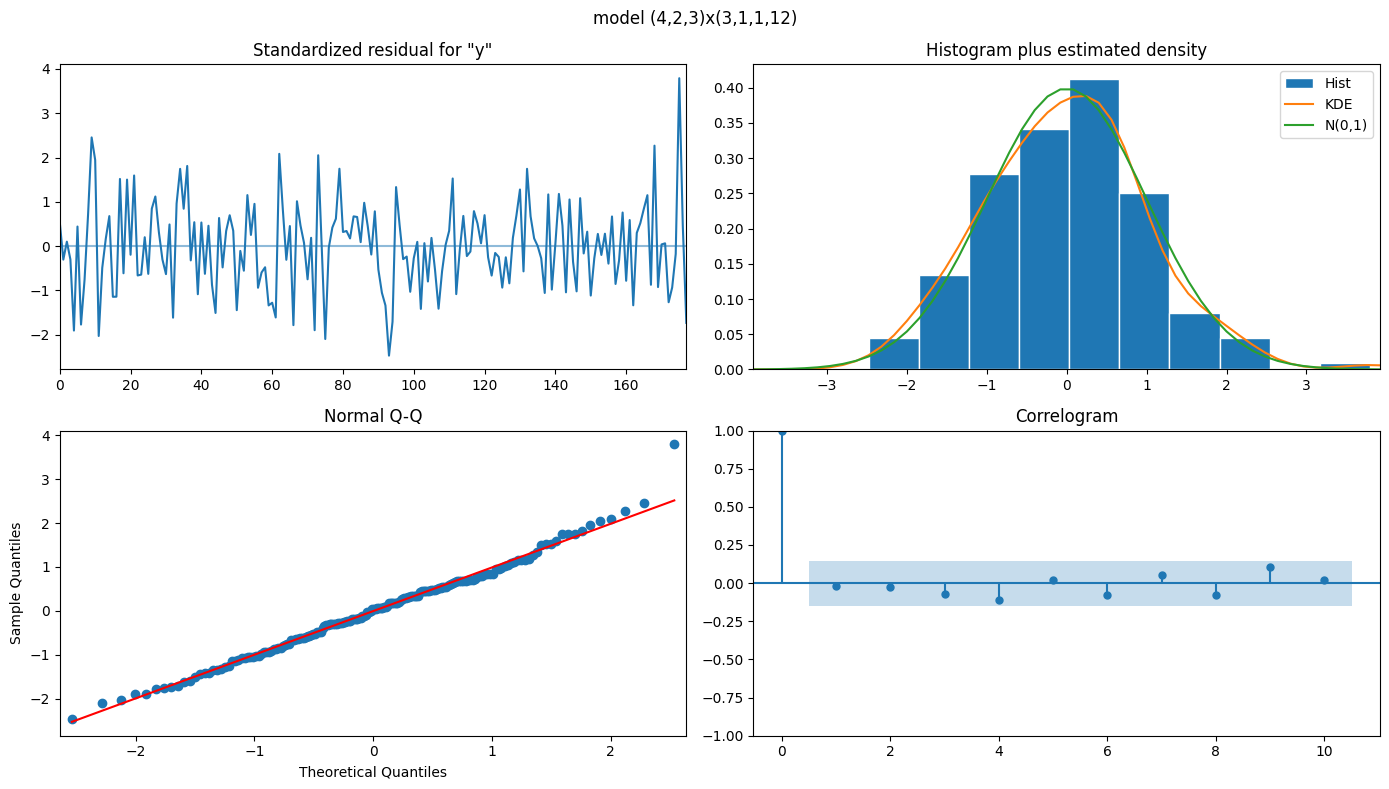

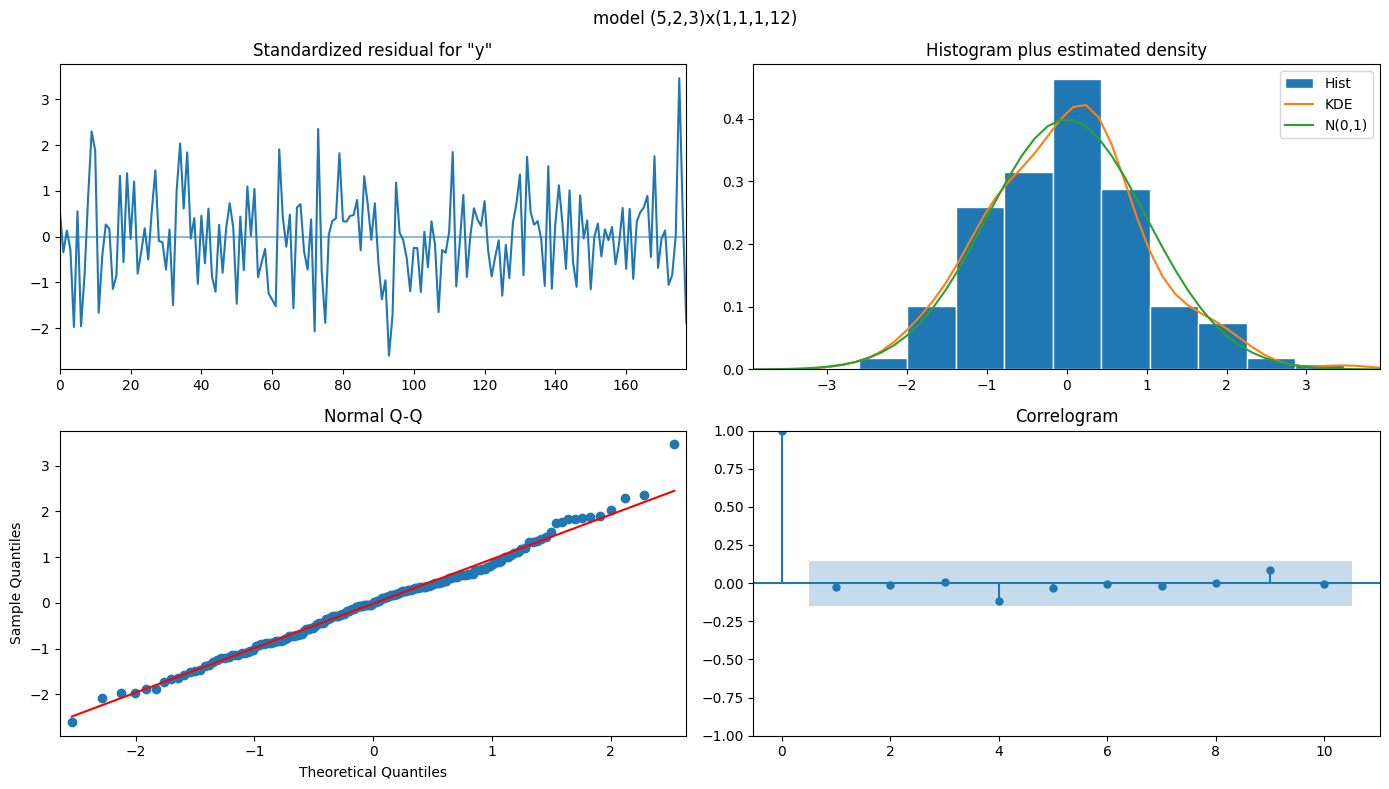

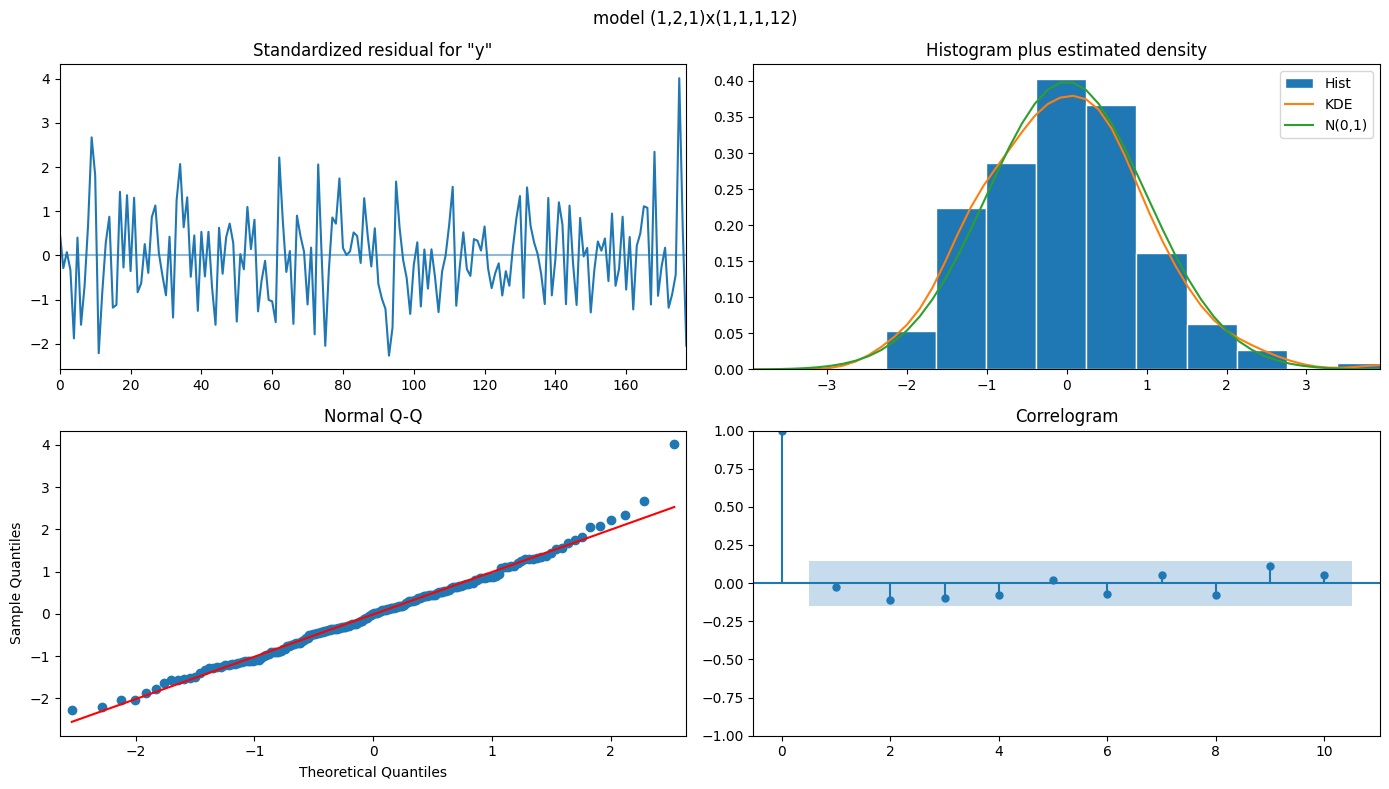

In [10]:
#compute predictions based on the models here and then see if the residuals are normally distributed
#use sarimax
model1 = ss.tsa.statespace.sarimax.SARIMAX(co2, 
                                order=(4,2,3), 
                                seasonal_order=(3,1,1,12), 
                                trend='c').fit(disp=False)
model2 = ss.tsa.statespace.sarimax.SARIMAX(co2, 
                                order=(5,2,3), 
                                seasonal_order=(1,1,1,12), 
                                trend='c').fit(disp=False)
model3 = ss.tsa.statespace.sarimax.SARIMAX(co2, 
                                order=(1,2,1), 
                                seasonal_order=(1,1,1,12), 
                                trend='c').fit(disp=False)


model1.plot_diagnostics(figsize=(14, 8))
plt.suptitle("model (4,2,3)x(3,1,1,12)")
plt.tight_layout()
plt.show()
model2.plot_diagnostics(figsize=(14, 8))
plt.suptitle("model (5,2,3)x(1,1,1,12)")
plt.tight_layout()
plt.show()
model3.plot_diagnostics(figsize=(14, 8))
plt.suptitle("model (1,2,1)x(1,1,1,12)")
plt.tight_layout()
plt.show()


Just from looking at the normality diagnostics plots there is no real outliner to identifier, not in a good or bad way. Maybe the second model looks like it does the worst job judging by the histogram, but that`s actually the model that has both top performance and low complexity. 

- Compare the best model you found with the one from autoarima.


In [11]:
#autoarima
model_auto = pm.auto_arima(co2_train, 
                      start_p=0, start_q=0,
                      test='adf',       # Use adftest to find optimal 'd'
                      max_p=5, max_q=3, # Maximum p and q
                      m=12,             # Seasonality
                      start_P=0, start_Q=0,
                      max_P=4, max_Q=1, # Maximum p and q
                      seasonal=True,    # Seasonal ARIMA
                      d=2,           # Let model determine 'd'
                      D=None,              # Seasonal difference
                      trace=True,       # Print status on the fits
                      error_action='ignore',  
                      suppress_warnings=True, 
                      stepwise=True)    # Stepwise search to find the best model

Performing stepwise search to minimize aic
 ARIMA(0,2,0)(0,1,0)[12]             : AIC=304.935, Time=0.01 sec
 ARIMA(1,2,0)(1,1,0)[12]             : AIC=192.247, Time=0.07 sec
 ARIMA(0,2,1)(0,1,1)[12]             : AIC=inf, Time=0.23 sec
 ARIMA(1,2,0)(0,1,0)[12]             : AIC=245.045, Time=0.01 sec
 ARIMA(1,2,0)(2,1,0)[12]             : AIC=190.184, Time=0.21 sec
 ARIMA(1,2,0)(3,1,0)[12]             : AIC=187.731, Time=0.34 sec
 ARIMA(1,2,0)(4,1,0)[12]             : AIC=183.702, Time=0.87 sec
 ARIMA(1,2,0)(4,1,1)[12]             : AIC=inf, Time=4.78 sec
 ARIMA(1,2,0)(3,1,1)[12]             : AIC=inf, Time=2.04 sec
 ARIMA(0,2,0)(4,1,0)[12]             : AIC=252.047, Time=0.65 sec
 ARIMA(2,2,0)(4,1,0)[12]             : AIC=168.234, Time=1.38 sec
 ARIMA(2,2,0)(3,1,0)[12]             : AIC=170.651, Time=0.61 sec
 ARIMA(2,2,0)(4,1,1)[12]             : AIC=169.966, Time=3.35 sec
 ARIMA(2,2,0)(3,1,1)[12]             : AIC=inf, Time=2.45 sec
 ARIMA(3,2,0)(4,1,0)[12]             : AIC=158.67

In [12]:
print(model_auto.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  172
Model:             SARIMAX(5, 2, 0)x(4, 1, 0, 12)   Log Likelihood                 -61.424
Date:                            Thu, 12 Mar 2026   AIC                            142.848
Time:                                    14:41:33   BIC                            173.474
Sample:                                         0   HQIC                           155.286
                                            - 172                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.0303      0.078    -13.199      0.000      -1.183      -0.877
ar.L2         -0.8030      0.103   

Doesnt settle on the same model parameters as the grid search method, and the AIC and BIC are higher for the AutoARIMA model(145 compared to 119, 131 and 140 for the AIC for example). This means the better model is the one found by SARIMAX grid search. Here is still also the diagnostics of the autoARIMA model, just for comparison:

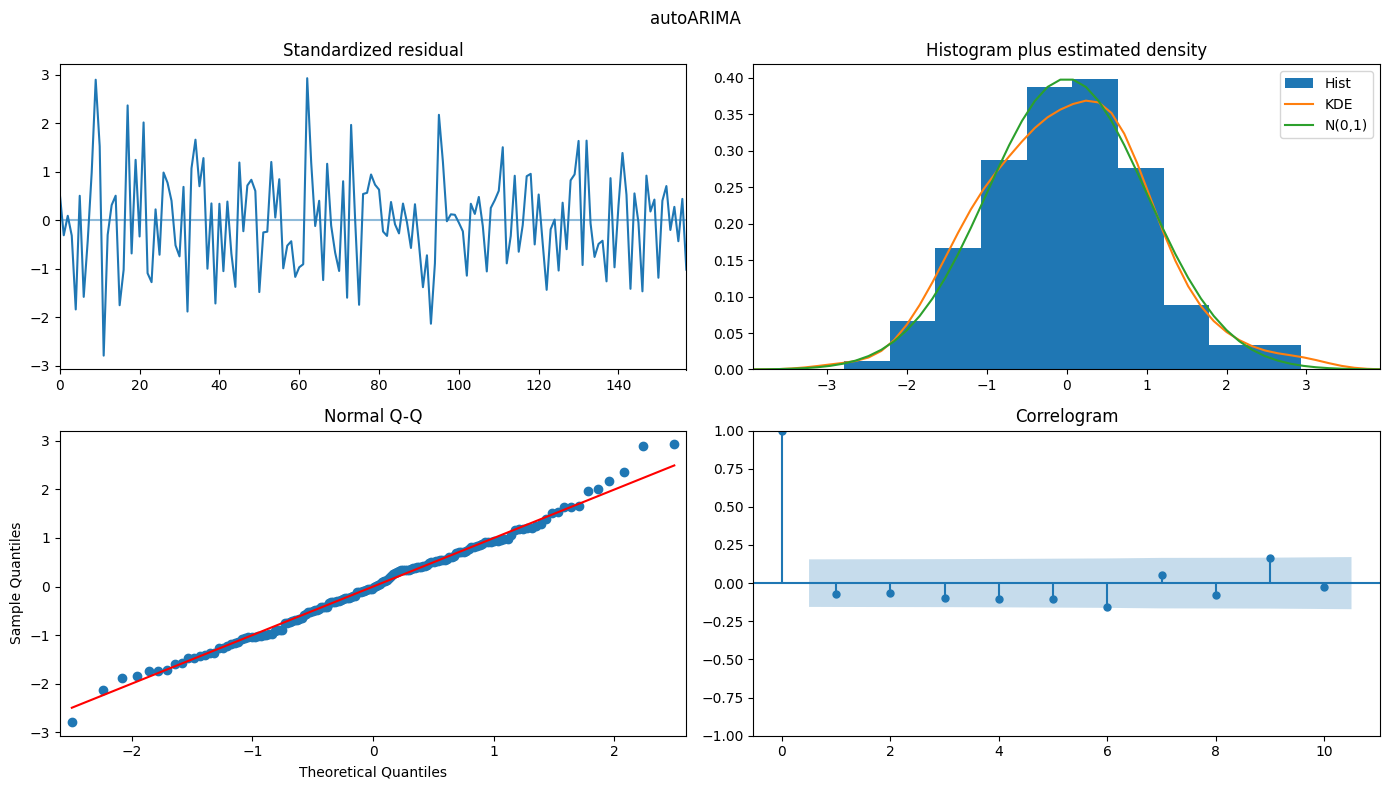

In [13]:
model_auto.plot_diagnostics(figsize=(14, 8))
plt.suptitle("autoARIMA")
plt.tight_layout()

## Chapter 06

### Exercise 

- Download and plot the historical closing prices of Tesla (``TSLA``) and Equinor (``EQNR``) for the years ``2019-12-31``- ``2022-12-31``.
- For each time series:
    - Test if the time series look stationary.

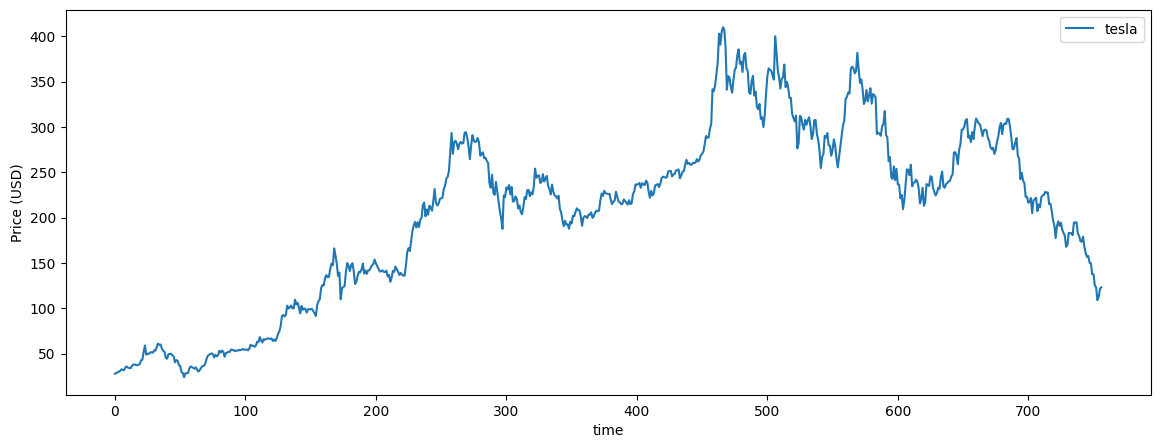

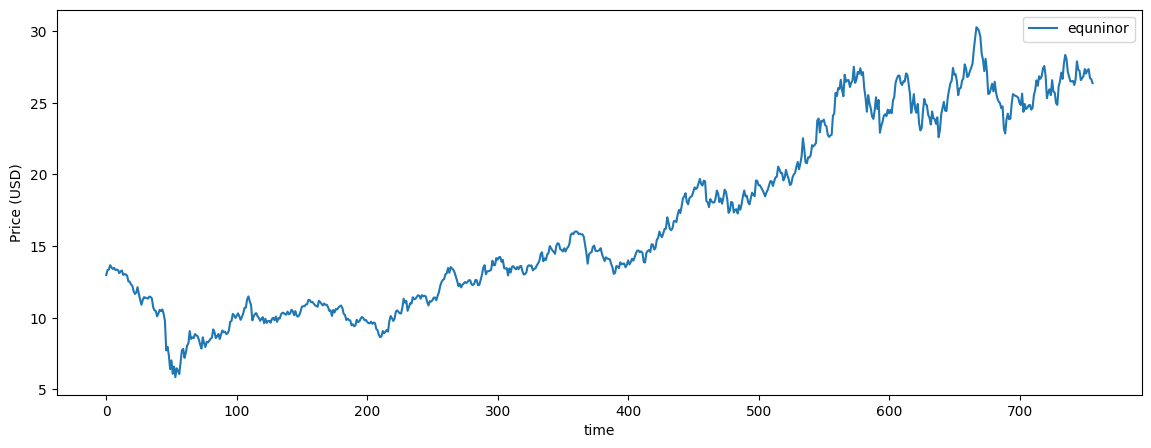

In [41]:
def get_data(tickerSymbol, start, end):

    # Get data on the ticker
    tickerData = yf.Ticker(tickerSymbol)

    # Get the historical prices for this ticker
    tickerDf = tickerData.history( start=start, end=end)
    
    return tickerDf
    
data_t = get_data('TSLA', start='2019-12-31', end='2022-12-31')
data_e = get_data('EQNR', start='2019-12-31', end='2022-12-31')

tesla = np.array(data_t["Close"])
equinor = np.array(data_e["Close"])

plt.figure(figsize=(14, 5))
plt.plot(tesla, label="tesla")
plt.xlabel("time")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(equinor, label="equninor")
plt.xlabel("time")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()


In [42]:
#test stationarity, use ADF test and chunks analysis
#tesla
adf, pvalue, usedlag, nobs, critical_values, icbest = adfuller(tesla, regression = "ct")
print(f"ADF {adf:.2f}")
print(f"p value: {pvalue:.2f}")

print(tesla.shape)
chunks_tesla = np.split(tesla[:-1], indices_or_sections=21)

print("{}\t | {}\t\t | {}".format("Chunk", "Mean", "Variance"))
print("-" * 35)
for i, chunk in enumerate(chunks_tesla, 1):
    print("{:2}\t | {:.5}\t | {:.5}".format(i, np.mean(chunk), np.var(chunk)))


ADF -0.93
p value: 0.95
(757,)
Chunk	 | Mean		 | Variance
-----------------------------------
 1	 | 42.43	 | 105.85
 2	 | 38.926	 | 66.805
 3	 | 52.76	 | 10.866
 4	 | 81.297	 | 291.92
 5	 | 122.59	 | 451.82
 6	 | 141.35	 | 34.355
 7	 | 187.8	 | 930.31
 8	 | 272.59	 | 283.9
 9	 | 223.87	 | 175.58
10	 | 216.34	 | 381.56
11	 | 215.02	 | 82.087
12	 | 238.2	 | 80.995
13	 | 297.47	 | 2832.6
14	 | 349.78	 | 508.63
15	 | 323.73	 | 908.48
16	 | 310.28	 | 1474.2
17	 | 276.23	 | 1624.2
18	 | 239.58	 | 218.79
19	 | 293.35	 | 110.17
20	 | 239.6	 | 999.74
21	 | 167.85	 | 629.84


There are large changes in mean (between 38 and over 300) and even larger in variance (between 10 and 2832). The time series is not stationary. 

In [43]:
chunks_equinor = np.split(equinor[:-1], indices_or_sections=21)

print("{}\t | {}\t\t | {}".format("Chunk", "Mean", "Variance"))
print("-" * 35)
for i, chunk in enumerate(chunks_equinor, 1):
    print("{:2}\t | {:.5}\t | {:.5}".format(i, np.mean(chunk), np.var(chunk)))

Chunk	 | Mean		 | Variance
-----------------------------------
 1	 | 12.425	 | 0.74934
 2	 | 8.3547	 | 2.2857
 3	 | 9.187	 | 0.65503
 4	 | 10.178	 | 0.19527
 5	 | 10.731	 | 0.1035
 6	 | 9.626	 | 0.23934
 7	 | 10.86	 | 0.39454
 8	 | 12.531	 | 0.2836
 9	 | 13.51	 | 0.12144
10	 | 14.544	 | 0.50484
11	 | 14.509	 | 0.6903
12	 | 14.799	 | 0.80387
13	 | 18.13	 | 0.94707
14	 | 18.34	 | 0.38727
15	 | 20.069	 | 0.76436
16	 | 24.574	 | 3.162
17	 | 25.289	 | 1.5316
18	 | 24.656	 | 1.1874
19	 | 27.234	 | 1.8309
20	 | 25.164	 | 1.146
21	 | 26.642	 | 0.63873


There is much less variability in mean and variance. This time series might be stationary although it does look like it has a trend. I can do a ADF test as a backup test. 

In [44]:
#ADF test on equinor ts
adf, pvalue, usedlag, nobs, critical_values, icbest = adfuller(equinor, regression = "c")
print(f"ADF {adf:.2f}")
print(f"p value: {pvalue:.2f}")

adf, pvalue, usedlag, nobs, critical_values, icbest = adfuller(equinor, regression = "ct")
print(f"ADF {adf:.2f}")
print(f"p value: {pvalue:.2f}")


ADF -0.44
p value: 0.90
ADF -3.60
p value: 0.03


The test passes when taking the trend into account but not without it. So the time series is not stationary per se, but after removing the trend it will probably be. 

- Compute the Hurst coefficient for both time series.
- Which stock would you like to invest into? Motivate your answer based on the tests and the value of $H$.

In [45]:
#compute Hurst coeff
def hurst(ts):  
    # Create the range of lag values
    lags = range(2, 100)
    # Calculate the array of the variances of the lagged differences
    tau = [np.var(np.subtract(ts[lag:], ts[:-lag])) for lag in lags]
    # Use a linear fit to estimate the Hurst exponent
    poly = np.polyfit(np.log(lags), np.log(tau), 1)
    # Return the Hurst exponent from the polyfit output
    return poly[0]/2.0

hurst_tesla = hurst(tesla)
hurst_equinor = hurst(equinor)

print(f"hurst coefficient tesla: {hurst_tesla:.2f}")
print(f"hurst coefficient equinor: {hurst_equinor:.2f}")

hurst coefficient tesla: 0.46
hurst coefficient equinor: 0.33


Both coefficients are below 0.5, so they don't indicate a strong trend. Tesla with a coefficient of 0.46 is closer to a random walk or even trending, while equinor is more clearly < 0.5 which means mean reverting. This seems counterintuitive as when looking at the plots it seems like equinor is trending.

According to the hurst coefficients equinor is the safer choice to invest in longterm as it probably will revert to its mean after a while if not something out of the ordinary happens. But as it is above the mean currently this also means it will probably drop to get back to the mean which means losing money. But when Tesla has an upward trend, and this seems to be the case here, it might be a good investment choice as it can be expected to continue rising. So this might be the better choice here.

- Simulate the stock prices using GBM.
- Which simulation seems to be more reliable? The one for Tesla or Equinor? 
- To motivate your answer: 
    1. compute the simulation at least 100 times.
    2. Compute the MSE between the true stock prices and the simulated ones.
    3. Compare the expected value of the MAPE for the two stocks.

GBM: $S(t) = S_0 \exp\left((\mu - \frac{1}{2} \sigma^2)t + \sigma W(t)\right)$

MSE tesla: 2189
MSE equinor: 56
MAPE tesla: 42.73 %
MAPE equinor: 76.71 %


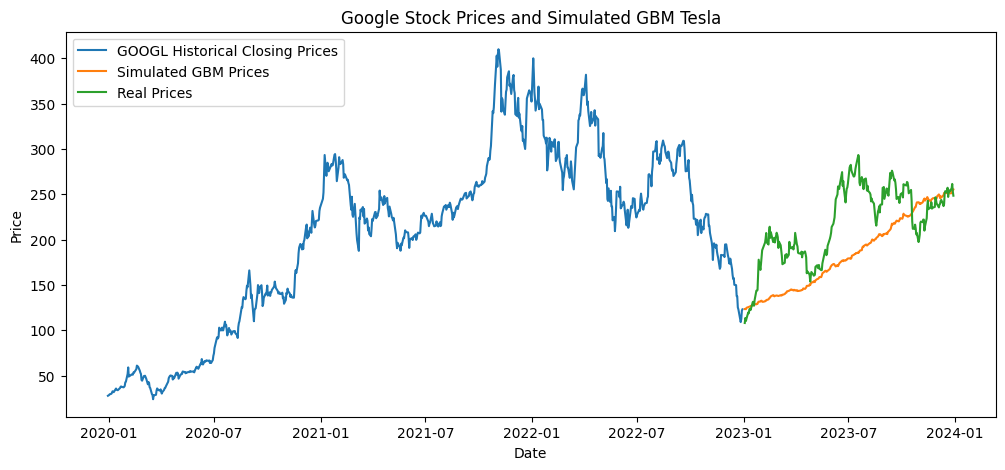

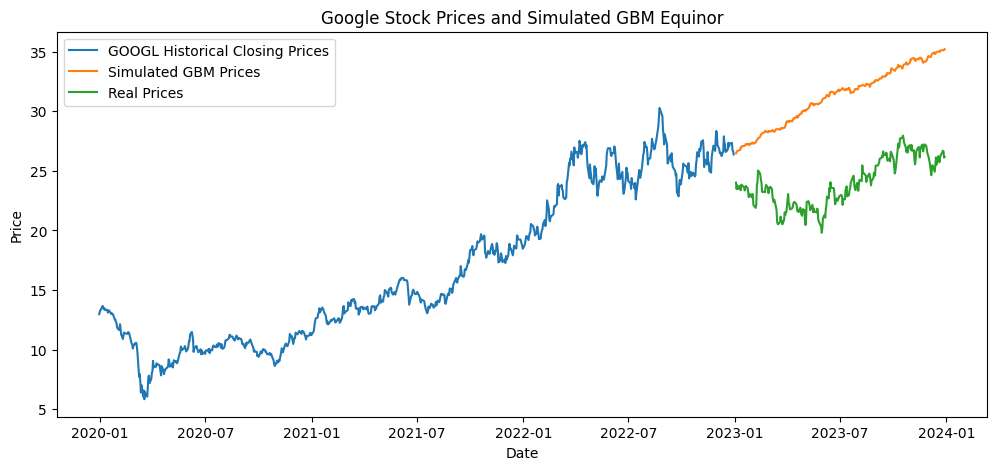

In [173]:
##set up parameters for GBM
#identical for both ts:
T = 1  #time period in years (for the prediction)
N = int(len(tesla)/3)-2 #number of timesteps
dt = T/N #time step in years
t  = np.linspace(0, T, N)
#tesla
S0_tesla = tesla[-1] #last point in the data
mu_tesla = data_t["Close"].pct_change().mean() * N #annualized mean
sigma_tesla = data_t["Close"].pct_change().std() * np.sqrt(N) #annualized std
#equinor
S0_equinor = equinor[-1]
mu_equinor = data_e["Close"].pct_change().mean() * N
sigma_equinor= data_e["Close"].pct_change().std() * np.sqrt(N)

#calculate GBM for 100 paths
def GBM_simulation(mu, sigma, time_step, S0):
    paths = []
    for _ in range(100):
        W = np.cumsum(np.random.standard_normal(size=N))*np.sqrt(dt)
        X = (mu - 0.5 * sigma**2) * time_step + sigma * W
        paths.append(S0 * np.exp(X))
    path_mean = np.array(paths).mean(axis=0)
    path_std = np.array(paths).std(axis=0)
    return path_mean, path_std

GBM_tesla_m, GBM_tesla_std = GBM_simulation(mu_tesla, sigma_tesla, t, S0_tesla)
GBM_equinor_m, GBM_equinor_std = GBM_simulation(mu_equinor, sigma_equinor, t, S0_equinor)

#download real data for the following year to compare to simulation
tesla_compare = get_data('TSLA', start='2022-12-31', end='2023-12-31')
equinor_compare = get_data('EQNR', start='2022-12-31', end='2023-12-31')

#plot of the simulated GBM and the real stock prices
plt.figure(figsize=(12, 5))
plt.plot(data_t["Close"].index, tesla, label='GOOGL Historical Closing Prices')
plt.plot(tesla_compare["Close"].index, GBM_tesla_m, label='Simulated GBM Prices')
#plt.fill_between(tesla_compare["Close"].index, GBM_tesla_m-0.05*GBM_tesla_std, GBM_tesla_m+0.05*GBM_tesla_std, color='tab:orange', alpha=0.2, label='95% CI')
plt.plot(tesla_compare['Close'], label='Real Prices')
plt.legend(loc='upper left')
plt.title('Google Stock Prices and Simulated GBM Tesla')
plt.xlabel('Date')
plt.ylabel('Price')

plt.figure(figsize=(12, 5))
plt.plot(data_e["Close"].index, equinor, label='GOOGL Historical Closing Prices')
plt.plot(equinor_compare["Close"].index, GBM_equinor_m, label='Simulated GBM Prices')
#plt.fill_between(tesla_compare["Close"].index, GBM_tesla_m-0.05*GBM_tesla_std, GBM_tesla_m+0.05*GBM_tesla_std, color='tab:orange', alpha=0.2, label='95% CI')
plt.plot(equinor_compare['Close'], label='Real Prices')
plt.legend(loc='upper left')
plt.title('Google Stock Prices and Simulated GBM Equinor')
plt.xlabel('Date')
plt.ylabel('Price')

#calculate MSE between predicted and real
tesla_mse = mse(GBM_tesla_m, tesla_compare["Close"], axis=0)
equinor_mse = mse(GBM_equinor_m, equinor_compare["Close"], axis=0)

print(f"MSE tesla: {tesla_mse:.0f}")
print(f"MSE equinor: {equinor_mse:.0f}")

#calculate expected MAPE for both stocks
tesla_mape = np.sum( (np.abs((tesla_compare["Close"] - GBM_tesla_m)/tesla_compare["Close"])) ).mean()
equinor_mape = np.sum( (np.abs((equinor_compare["Close"] - GBM_equinor_m)/equinor_compare["Close"])) ).mean()

print(f"MAPE tesla: {tesla_mape:.2f} %")
print(f"MAPE equinor: {equinor_mape:.2f} %")

As the two stocks are in quite different price ranges MAPE might be more representative as it shows the relative error and not the absolute error. MSE is mostly lower for the Equinor stocks but MAPE is lower for the equinor stocks. I thinks this makes Tesla the more reliable prediction here.  